# Отчет по модулю А

### 1. Цель модуля
Целью является разработать автоматизированную систему взаимодействующую с DWH (Data Warehouse) состояшего из слоев:
- Сырых данных
- Ядра
- Витрин данных

### 2. Анализ требований
В том числе необходимо:
- правильно спроектировать единую БД PostgreSQL
- разделить внтури все на логические слои исходя из предназначения данных
- выделить только основные сущности, таблицы и справочники без создания лишних таблиц данных, которые будут лишь только нагружать систему

Реализованная система должна обеспечивать и гарантировать единую версию правды, предусматривать возможность просмотра истории за 180 дней, поддерживать real-time мониторинг, прогнозирование потока и информации о нем на 30/60/120 дней.

Необходимо предусмотреть возможность расширяемости источников данных с разных мест и разных камер видеонаблюдения например, в том числе поддерживать обработку хронологических данных.

### 3. Технологический стек
#### 3.1 Рекомендуемый стек
- Python - основной язык, предусмотренный архитектурой, для реализации полноценного пайплайна и обработки
- YOLO - модель, необходимая для детекции транспортных средств
- PostgreSQL - хранилище данных
- SQL как основной язык управления данными
- Yandex DataLens - предусмотрен для бизнес аналитики и построения графиков
- Jupyter Notebook - для документирования
- draw.io - будет необходим для построения диаграмм архитектуры и данных

#### 3.2 Обоснование стека
- PostgreSQL имеет должный функционал для работы с данными, созданием витрин и управления нормализованными данными
- Имеет простую интеграцию с python через sqlalchemy и с Yandex DataLens
- Yolo Ultralytics гарантирует качественный и быстро работающий CV контур для формирования исходных данных
- DataLens позволяет просто и быстро построить данные подключив источники данных. Сформировать итоговый дашборд быстро и интуитивно просто, понятно.  

### 4. Архитектура решения
Архитектурный подход, используемые для решения - гибрид raw/core/dm - сырой слой, интеграционный слой, витринный слой.

В качестве архитектурного решения выбран универсальный вариант: сырые данные событий детекции и прочая служебная информация от модели сохраняются в слое **raw**, потом даные проходят нормализацию в core слое, после чего из обработанных сущностей формируются витрины dm для мониторинга, хронологии анализа данных и возможного прогнозирования.
В рамках ограниченного конкурсного времени такой подход является наиболее лучшим по принципу, качество-время, также он обеспечивает прозрачность потока данных, однообразие метрик и плотную прямую интеграцию с PostgreSQL и Yandex DataLens.


### 5. Целевая архитектура
#### 5.1 Общая логика системы
Пайплайн должен быть устроен следующим образом
1. Источник сырых данных (видеопоток)
2. Модуль распознования: модель определяет транспортные средства и формирует записи о событиях детекции/трекинга
3. Отправка в PostgreSQL - данные загружаются в таблицы
4. Интерпретация - из сырых данных образуются готовые события отслеживания а также агрегаты по интервалам времени
5. Представления (витрины) данных, которые формируются из подготовленных данных
6. Дашборд как потребитель аналитического контура: Yandex DataLens

### 6. Проектирование слоев данных
#### 6.1 Слой raw
Назначение: сохранение сырых данных полученных от модели
Основные таблицы:
* video_registry - записи о запуске анализа потока
* detection_events - события детекции по кадрам
* load_log - журнал загрузок
* external_factors - внешние факторы если они будут учитываться позднее

#### 6.2 Слой core
Назначение: преобразование полностью сырых данных в бизнес-понятные сущности
Основные таблицы:
* camera - камеры видеонаблюдения
* track - трек движения объекта
* place - места видеонаблюдений
* time_slot - временные интервалы для агрегаций
* vehicle_type - тип транспорта

#### 6.3 Слой dm
Назначение: готовые витрины для дашборда и модели прогноза
Основные витрины:
* traffic_now - текущее состояние потока
* traffic_history - исторические данные
* traffic_structure - состав потока по типам тс и их количеству
* segment_daily_profile - профиль участка по дням
* predict_features - признаки для прогнозирования
* predict_result - результаты прогнозирования
* monitoring - витрина для наблюдения за состоянием работы контура
* now_congestion - витрина для отображеия текущей загруженности

### 7. Концептуальная модель данных
![Концептуальная модель данных.png](<attachment:Концептуальная модель данных.png>)
Мною была проработана концептуальная модель данных, котороая содержит в себе все проектируемые таблицы и их поля, также содержит связи между таблицами. Таблицы следует разбить на схемы исходя из предназначения таблиц.
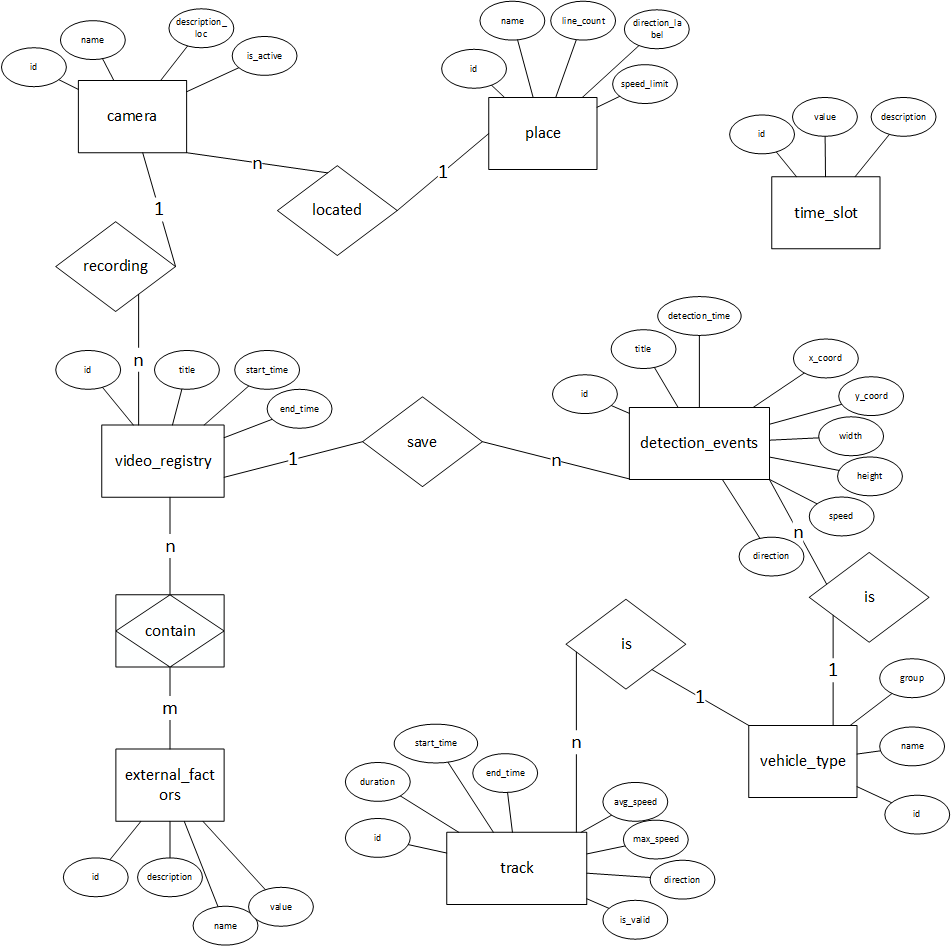

### 8. Физическая модель данных
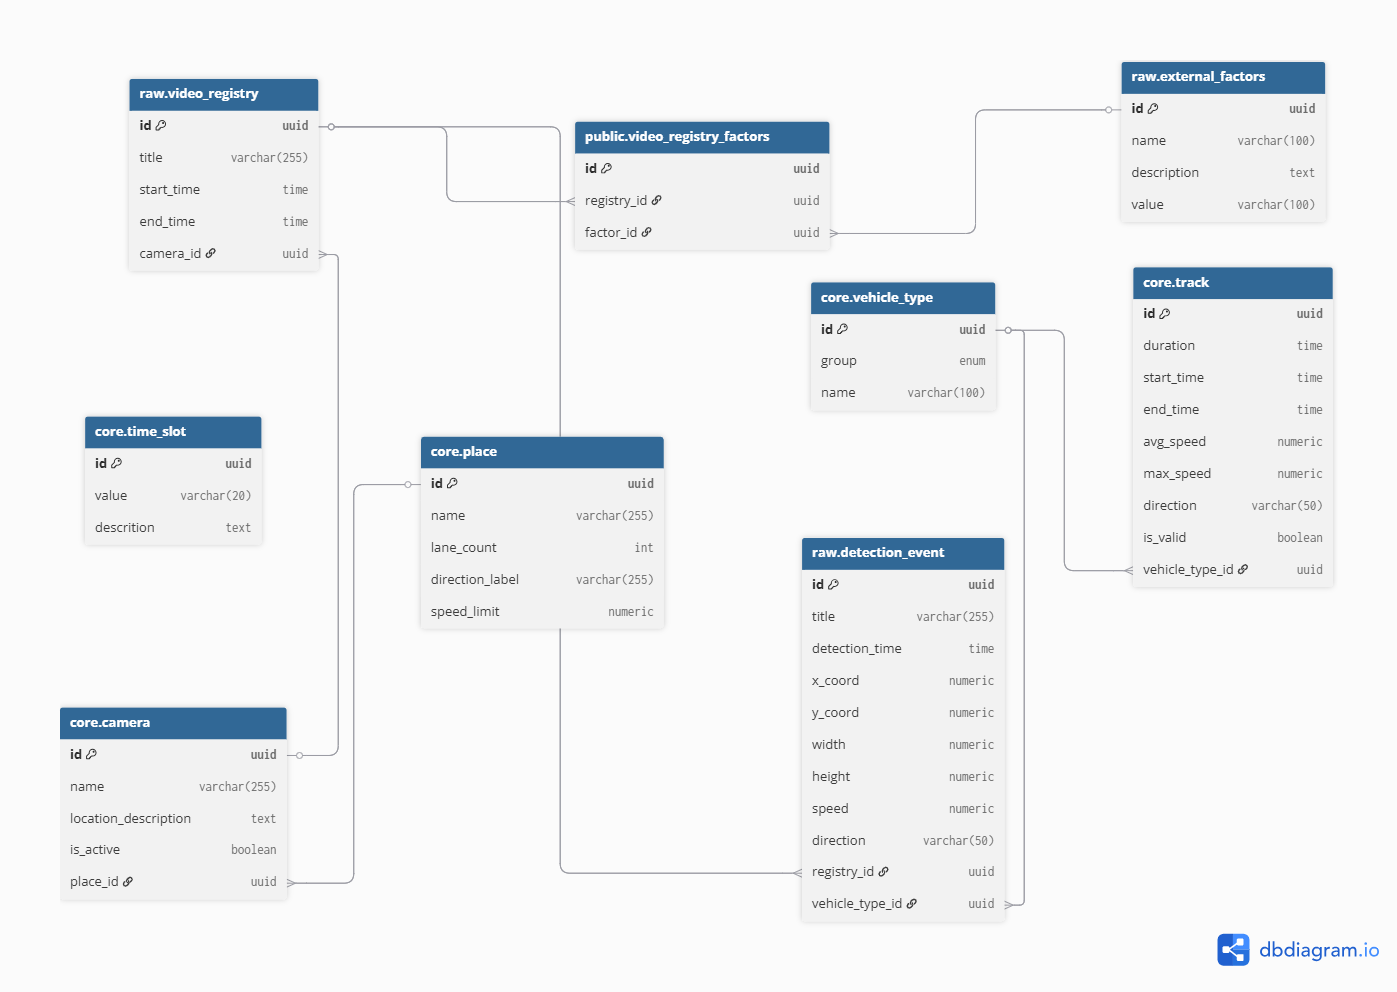
Физическая модель данных содержит более детализированную информацию об объектах, атрибутах и связях. Прописаны ограничения внешних ключей а также типы данных полей.

### 9. Паспорта витрин

#### 9.1 Витрина dm.traffic_now
**Назначение:** оперативный мониторинг текущего состояния транспортного потока по камерам и участкам.
**Источники:** camera, place, video_registry, detection_event, vehicle_type
**Обновление:** 1-5 минут
**Бизнес-вопрос:** какова текущая загруженность участка, какая средняя скорость, как распределяется поток по типам ТС.
**Потребитель:** аналитические отделы и аналитики
**Гранулярность:** высокая (текущее состояние транспортного потока)
**Состав витрины:**
- временной интервал
- камера
- участок
- интенсивность (кол-во detection_events)
- средняя скорость
- кол-во уникальных событий

#### 9.2 Витрина dm.traffic_history
**Назначение:** анализ исторических данных транспортного потока
**Источники:** detection_event, video_registry, camera, place, vehicle_type
**Обновление:** ежечасно / ежедневно.
**Бизнес-вопрос:** как меняется трафик во времени, в какие часы наблюдаются пики, как ведёт себя скорость.
**Потребитель:** специалисты в области стратегического планирования и оценки, аналитические отделы и аналитики
**Гранулярность:**  средняя (статистиика по часам)
**Состав витрины:**
- дата
- час / интервал
- участок
- интенсивность
- средняя скорость
- медианная скорость
- максимальная скорость

#### 9.3 Витрина dm.traffic_structure
**Назначение:** анализ структуры транспортного потока по типам транспортных средств
**Источники:** detection_event, vehicle_type, video_registry, place
**Обновление:** каждые 10–30 минут
**Бизнес-вопрос:** какие типы ТС преобладают на участке и как меняется их доля
**Потребитель:** отделы аналитики
**Гранулярность:** высокая (короткий временной интервал)
**Состав витрины:**
- временной интервал
- участок
- тип ТС
- кол-во
- доля %

#### 9.4 Витрина dm.speed_violations
**Назначение:** контроль превышения скорости на участках.
**Источники:** detection_event, place, camera, video_registry
**Обновление:** каждые 1–5 минут
**Бизнес-вопрос:** сколько нарушений скорости происходит, где и в какое время
**Потребитель:** государственная авто инспекция (государственный орган)
**Гранулярность:** переменная (в зависимости от выбраннного временного интервала)
**Состав витрины:**
- интервал времени
- камера
- участок
- разрешённая скорость (speed_limit)
- зафиксированная скорость
- превышение (разница)

#### 9.5 Витрина dm.external_impact
**Назначение:** оценка влияния внешних факторов на транспортный поток
**Источники:** video_registry, video_registry_factors, external_factors, detection_event, place
**Обновление:** ежечасно
**Бизнес-вопрос:** как погодные условия, события и другие факторы влияют на интенсивность и скорость
**Потребитель:** гос органы и отделы статистики
**Гранулярность:** переменная (в зависимости от выбраннного временного интервала)
**Состав витрины:**
- временной интервал
- участок
- фактор (например: дождь, ночь, событие)
- значение фактора
- интенсивность
- средняя скорость
- изменение интенсивности (по сравнению с базой)
- изменение скорости

#### 9.6 Витрина dm.avg_speed
**Назначение:** оценка средней скорости транспорта в потоке
**Источники:** detection_event, place, camera, video_registry
**Обновление:** 1 раз в 5 минут 
**Бизнес-вопрос:** С какой средней скоростью двигается транспорт на конкретном участке?
**Потребитель:** Отделы аналитики
**Гранулярность:** высокая
**Состав витрины:** 
- участок
- значение скорости
- максимальная скорость
- минимальная скорость


#### 9.6 Витрина dm.predict_result
**Назначение:** Предсказание загруженности потока
**Источники:** detection_event, place, camera, video_registry
**Обновление:** 1 раз в час
**Бизнес-вопрос:** Какая загруженность потока будет на определенном участке через какое то время.
**Потребитель:**
**Гранулярность:**
**Состав витрины:**
- 


#### Сводная таблица "Витрина - бизнес вопрос"
| # | Витрина | Бизнес вопрос |
| -- |----------|--------------|
| 1 | dm.traffic_now | Какова текущая загруженность участка, какая средняя скорость, как распределяется поток по типам ТС? |
| 2 | dm.traffic_history | Как меняется трафик во времени, в какие часы наблюдаются пики, как ведёт себя скорость? |
| 3 | dm.traffic_structure | Какие типы ТС преобладают на участке и как меняется их доля? |
| 4 | dm.speed_violations | Сколько нарушений скорости происходит, где и в какое время? |
| 5 | dm.external_impact | Как погодные условия, события и другие факторы влияют на интенсивность и скорость? |
| 6 | dm.avg_speed | С какой средней скоростью двигается транспорт на конкретном участке? |
| 7 | dm.predict_result | Какая загруженность потока будет на определенном участке через какое то время? |

### 10. Объяснение как архитектура поддерживает модули Б-Е
1. Модуль Б поддерживается за счет того, что нужно предусмотреть те таблицы, которые в дальнейшем будут использоваться в модуле Б
2. В модуле В придется использовать витрины для построения дашборда поэтому нужно их предусмотреть в модуле А
3. В модуле Г прорабатывается момент трансформации данных, обьясненная схема загрузки, поэтому нужно показать в модуле А логику потоков данных
4. Модуль Д использует метрики контроля качества работы системы, для чего нужно реализовать возможность писать данные в таблицы необходимые для этого. А продумать и спроектировать их нужно как раз таки в модуле А

### 11. Входные данные
В качестве входных данных предусматриваются следующие данные:
- Исторические CSV данные о потоке транспорта
- Видеопоток в виде трансляции
- Видеофайл
- Информация о внешних факторах

### 12. Единая версия правды
В формируемой в модулях Б - Е системе подразумевается поддержка принципа единой версии правды. Все модули системы и сущности, должны быть реализованы в соотвествии с этим принципом, в том числе единый DWH, единая система метрик, единые справочники, а также витрины как единственный источник DWH. 

### 13. Правила историчности
В реализуемой системе необходимо организовать хранение событий за 180 дней, временные поля, агрегаты по времени:
- 1 минута
- 10 минут
- 1 час
- 3 часа
- 1 день
- 1 неделя
- 1 месяц

Необходимо грамотно организовать работу с историческими данными, чтобы не грузить систему большим объемом данных, придя таким образом к партиционированию например или распределением данных на нескольких серверах.

### 14. Основные метрики
В качестве основных метрик выявлены следующие метрики:
- интенсивность транспортного потока
    * кол-во детекций
    * кол-во корректных детекций
    * кол-во треков
    * среднее время нахождения объекта в кадре
- средняя скорость
- загруженность
- доля типа ТС
- опасное сближение
- прогнозная загруженность

### 15. Вывод
По итогу мы получаем спроектированную архитектуру решения, которая работает с единым исчтоником данных, использует в анализе единые определения метрик. Система является автоматизированным решением, предусматривает возможность инкрементальной обработки.

По итогу у нас получается вот такой поток данных:
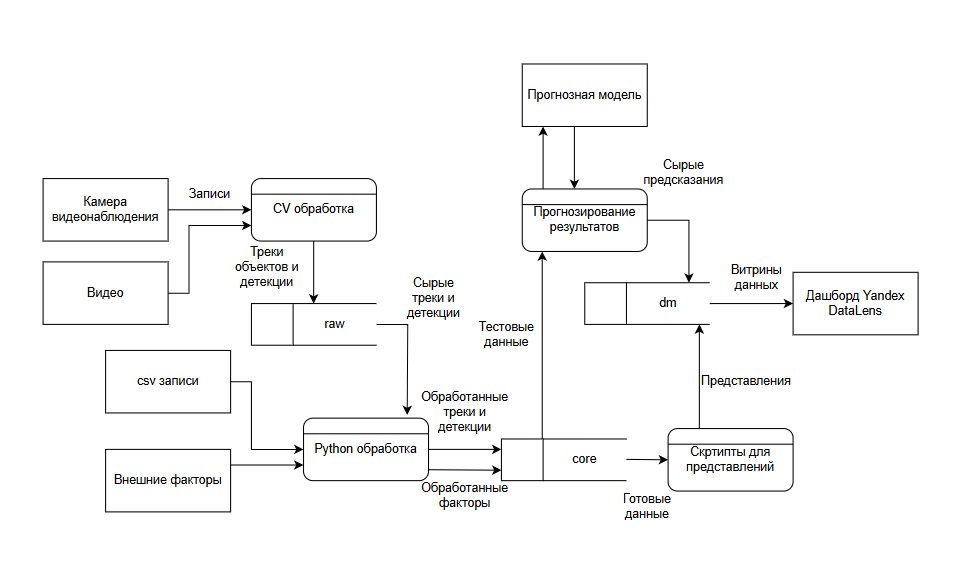
Диаграмма потока даных.

В результате мы спроектированную архитектуру системы для последующей реализации в модулях Б-Е, которая состоит из ядра аналитики, которое считывает видеопоток и транслирует опознанные объекты и их треки в базу данных в качестве сырых записей. Оттуда аналитический контур автоматически реализует нужные нам представления (мы напишем готовые представления данных которые при добавлении новых данных в таблицы продолжит нормально качественно функционировать). С аналитического контура данные будут получаться дашбордом, в котором будут строиться графики по данным, предсказания и будет формироваться раздел мониторинга.

Итоги:
- Единая версия правды обеспечивается использованием идиной базы данных PostgreSQL, в которой витрины расчитываются на основании согласованных нормализованных сущностей core слоя, что исключает расхождение определений метрик между потребителями.
- Описанная мною архитектура поддерживает масштабируемость, за счет добавления новых камер, новых мест наблюдения и новых представлений без необходимости переработки базового контура.
- Выбранный стек обеспечивает качественно и быстрое в рамках конкурсного времени выполнение задания и формирования единой функциональной и автоматизированной системы.
- Архитектура спроектирована таким образом что выполняет проектирование архитектуры, DWH, моделей данных и витрин.